In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Imports loaded")

✅ Imports loaded


In [2]:
# Pure-pandas technical indicators (no TA-Lib dependency)

def sma(series, window):
    """Simple Moving Average"""
    return series.rolling(window=window).mean()

def ema(series, window):
    """Exponential Moving Average"""
    return series.ewm(span=window, adjust=False).mean()

def rsi(series, window=14):
    """Relative Strength Index"""
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/window, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def macd(series, fast=12, slow=26, signal=9):
    """MACD: Moving Average Convergence Divergence"""
    ema_fast = ema(series, fast)
    ema_slow = ema(series, slow)
    macd_line = ema_fast - ema_slow
    signal_line = ema(macd_line, signal)
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

print("✅ Indicator functions defined")

✅ Indicator functions defined


In [3]:
# Load one stock to start (AAPL)
ticker = "AAPL"
path = Path(f"../data/raw/{ticker}.csv")

df = pd.read_csv(path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

print(f"✅ Loaded {len(df):,} rows for {ticker}")
print(f"📅 Range: {df.index.min().date()} → {df.index.max().date()}")
print(df.head())

✅ Loaded 3,774 rows for AAPL
📅 Range: 2009-01-02 → 2023-12-29
               Close      High       Low      Open      Volume
Date                                                          
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [4]:
# Compute indicators on Close price
price = df['Close']

df['SMA_20'] = sma(price, 20)
df['SMA_50'] = sma(price, 50)
df['EMA_12'] = ema(price, 12)
df['EMA_26'] = ema(price, 26)
df['RSI_14'] = rsi(price, 14)

macd_line, signal_line, histogram = macd(price)
df['MACD'] = macd_line
df['MACD_Signal'] = signal_line
df['MACD_Hist'] = histogram

print("✅ All indicators computed")
print(df[['Close', 'SMA_20', 'SMA_50', 'RSI_14', 'MACD']].tail())

✅ All indicators computed
                 Close      SMA_20      SMA_50     RSI_14      MACD
Date                                                               
2023-12-22  191.788757  191.856618  183.572859  54.672784  2.633141
2023-12-26  191.243912  192.018094  183.858864  53.090049  2.304751
2023-12-27  191.342972  192.154308  184.149424  53.354446  2.029104
2023-12-28  191.768951  192.362839  184.479567  54.540999  1.823998
2023-12-29  190.728775  192.490633  184.814828  51.121347  1.559539


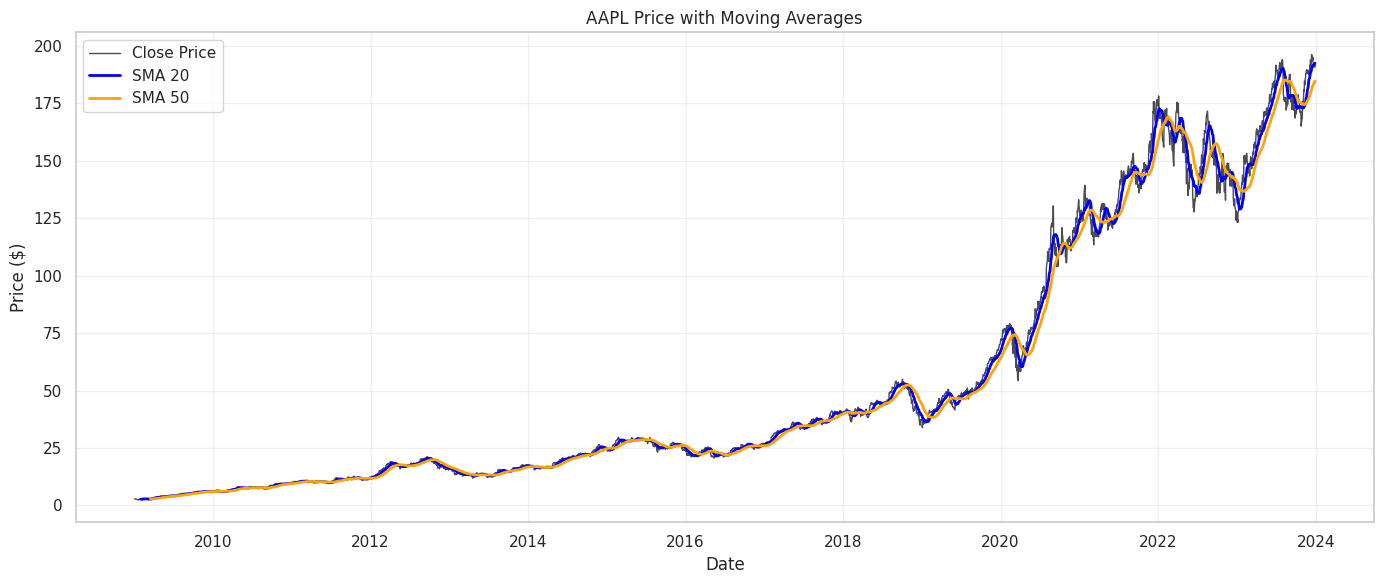

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', linewidth=1, alpha=0.7, color='black')
plt.plot(df.index, df['SMA_20'], label='SMA 20', linewidth=2, color='blue')
plt.plot(df.index, df['SMA_50'], label='SMA 50', linewidth=2, color='orange')
plt.title(f'{ticker} Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'../reports/{ticker}_price_sma.png', dpi=300)
plt.show()

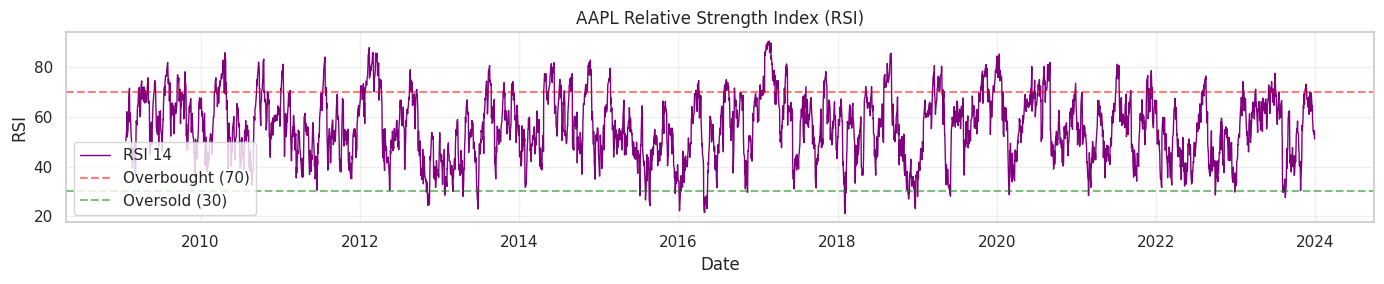

In [6]:
plt.figure(figsize=(14, 3))
plt.plot(df.index, df['RSI_14'], label='RSI 14', color='purple', linewidth=1)
plt.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
plt.axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
plt.title(f'{ticker} Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'../reports/{ticker}_rsi.png', dpi=300)
plt.show()

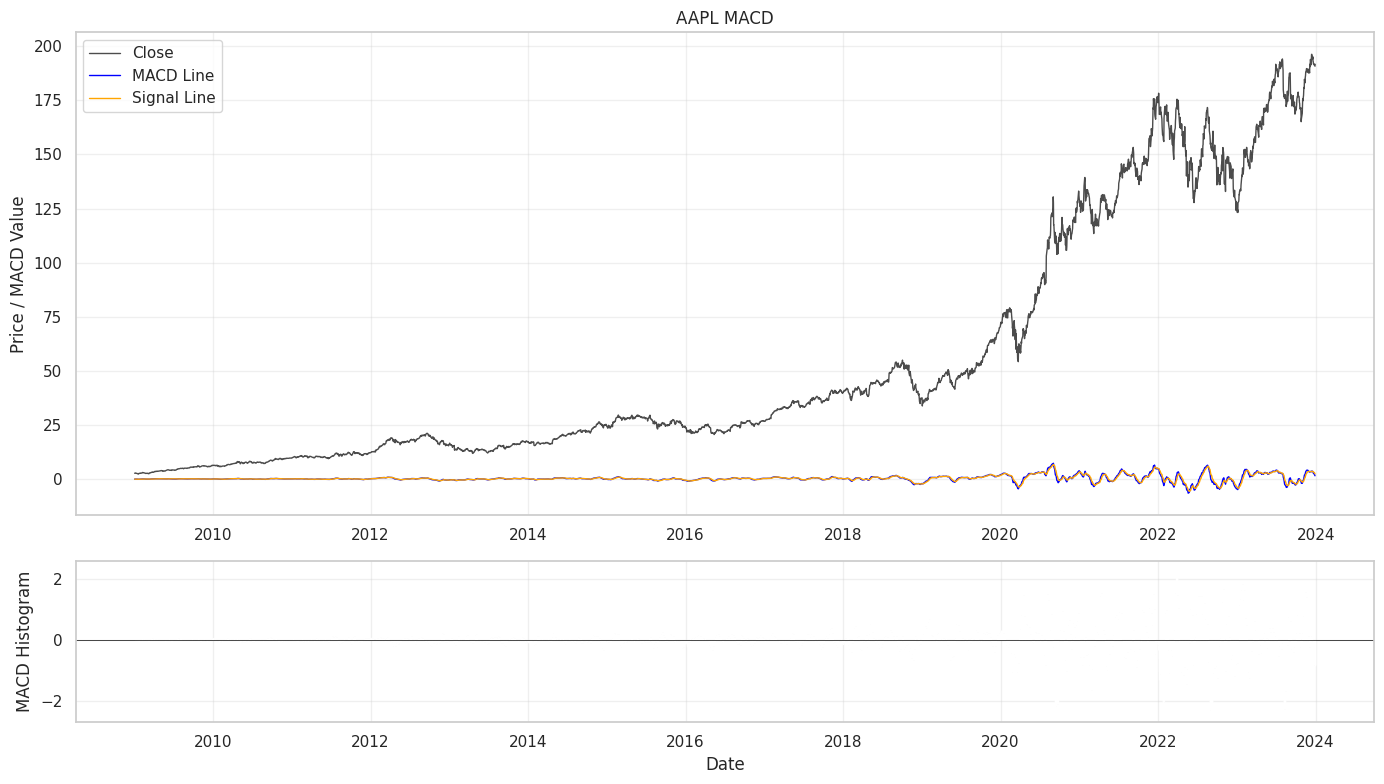

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Price + MACD lines
ax1.plot(df.index, df['Close'], label='Close', color='black', linewidth=1, alpha=0.7)
ax1.plot(df.index, df['MACD'], label='MACD Line', color='blue', linewidth=1)
ax1.plot(df.index, df['MACD_Signal'], label='Signal Line', color='orange', linewidth=1)
ax1.set_title(f'{ticker} MACD')
ax1.set_ylabel('Price / MACD Value')
ax1.legend()
ax1.grid(alpha=0.3)

# MACD Histogram
ax2.bar(df.index, df['MACD_Hist'], label='Histogram', color='gray', width=1)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('MACD Histogram')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'../reports/{ticker}_macd.png', dpi=300)
plt.show()